<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/4.chirps_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Packages and Setup

In [1]:
# Import libraries for data manipulation, numerical computing, visualization, and geospatial analysis
import pandas as pd  # Data manipulation and analysis
import ee  # Google Earth Engine Python API
import geemap  # Earth Engine mapping tools
import matplotlib.pyplot as plt  # Plot generation
import os  # Operating system interface for file operations
import seaborn as sns  # Statistical visualization

In [2]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 14  # Legend font size

In [3]:
# Authenticate with Google Earth Engine and initialize the project
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-curuai2')

In [4]:
# Optional: Mount Google Drive for Colab environment
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# Set directory paths for output results and working data
exp_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Results"
wrk_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Water Period Definitions"

# Time Series Display Function

In [6]:
def prepare_time_series_plot(df, var, title, color_palette=None):
    """
    Create and display a time series plot with predictions and observations.
    
    Parameters:
    - df: DataFrame containing the time series data
    - var: Variable name to plot on y-axis
    - title: Title for the plot and output file
    - color_palette: Color scheme for water periods (default: uses predefined palette)
    """
    
    # Sort dataframe by time to ensure chronological order
    df = df.sort_values(by='time_start')

    # Create figure and axis with appropriate size for visibility
    fig, ax = plt.subplots(figsize=(16, 6))   

    # Plot the variable as a gray line to show overall trend
    ax.plot(df['time_start'], df[var], alpha=0.5,
                color='gray', linestyle='-.', linewidth=1)
    
    # Extract unique water periods and define color palette
    water_periods = sorted(df['water_period'].unique())
    if color_palette is None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Map each water period to a specific color
    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}

    # Plot observations separately for each water period with distinct colors
    for water_period in water_periods:
        subset = df[df['water_period'] == water_period]
        ax.plot(subset['time_start'], subset[var],
                marker='o', markersize=6, alpha=0.5,
                color=colors[water_period], linestyle='none',
                label=f'{water_period}')

    # Set x-axis label
    ax.set_xlabel('Date')
    
    # Set y-axis label and output directory based on variable type
    if "TSS" in var:
        ax.set_ylabel('TSS (mg/L)')
        directory = os.path.join(exp_directory, "TSS")
    elif "area" in var:
        ax.set_ylabel("Area (km$^2$)")
        directory = os.path.join(exp_directory, "Area")
    elif "chirps" in var:
        ax.set_ylabel("Accumulated Precipitation \n(mm/Hidrological Period)")
        directory = os.path.join(exp_directory, "Precipitation")
    elif "discharge" in var:
        ax.set_ylabel("Mean Discharge \n(m$^3$/s)")
        directory = os.path.join(exp_directory, "Discharge")
    else:
        directory = exp_directory
    
    # Set title and legend
    ax.set_title(f"{title} vs Time")
    ax.legend(loc='best')

    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig(os.path.join(directory, f"{title}_time_series.jpg"), dpi=300)
    plt.show()
    plt.close()
    

# Import CHIRPS Precipitation Dataset

## CHIRPS Dataset Information
**Climate Hazards Center InfraRed Precipitation with Station data (CHIRPS)** is a 30+ year quasi-global rainfall dataset. 

**Data Characteristics:**
- Incorporates 0.05° resolution satellite imagery with in-situ station data
- Creates gridded rainfall time series for trend analysis and seasonal drought monitoring
- Spatial Resolution: 5,566 meters (approximately 5.5 km)

In [7]:
# Load daily CHIRPS precipitation data from Earth Engine
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")

## Import Regions of Interest

In [8]:
# Load two watershed boundary feature collections
floodplain = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_local')  # Local Curuai watershed
floodplain_2 = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_regional')  # Regional watershed

# Display floodplain information
floodplain

## Filter CHIRPS Collection by Date and Region

In [9]:
# Define the time range for analysis
startyear = 1984  # Start of CHIRPS dataset availability
endyear = 2025    # End of analysis period

In [10]:
# Create Earth Engine date objects for the analysis period (start and end dates)
startdate = ee.Date.fromYMD(startyear, 1, 1)  # January 1 of start year
enddate = ee.Date.fromYMD(endyear, 12, 31)    # December 31 of end year

In [11]:
# Filter CHIRPS collection by date range and geographic extent (floodplain)
chirps = chirps.select('precipitation').filterDate(startdate, enddate).filterBounds(floodplain_2)

# Display the total number of daily precipitation images available
print('Total number of images:', chirps.size().getInfo())

Total number of images: 15340


In [12]:
# Get the nominal pixel scale of CHIRPS data (5.5 km resolution)
scale = chirps.first().projection().nominalScale()

# Import Water Period Definitions Based on Óbidos Water Level

In [13]:
# Load water period definitions generated from hydrological analysis
df_period_limits = pd.read_csv(os.path.join(wrk_directory, 'water_period_limits.csv')).drop(columns=['Unnamed: 0'])

# Convert date columns to datetime format for proper temporal processing
df_period_limits['lim_next'] = pd.to_datetime(df_period_limits['lim_next'])
df_period_limits['lim_previous'] = pd.to_datetime(df_period_limits['lim_previous'])

# Sort by start date to ensure chronological order
df_period_limits = df_period_limits.sort_values(by='lim_next').reset_index(drop=True)


# Display last rows to verify data completeness
display(df_period_limits.tail())

,lim_previous,lim_next,water_period,year,month
223,2024-11-23,2025-03-09,R,2025,3
224,2025-03-09,2025-06-09,HW,2025,6
225,2025-06-09,2025-09-09,F,2025,9
226,2025-09-09,2025-12-09,LW,2025,12
227,2025-12-09,2026-01-01,R,2026,1


# Create Accumulated Precipitation Mosaics Grouped by Water Period

In [14]:
# Create accumulated rain composite mosaics for each water period
# Each mosaic represents the total precipitation accumulated during a specific hydrological period
list_images = []

# Iterate through each water period definition
for i in range(0, len(df_period_limits)):
    
    # Convert dates to strings formatted for Earth Engine
    start_date = df_period_limits['lim_previous'][i].strftime('%Y-%m-%d')
    end_date = df_period_limits['lim_next'][i].strftime('%Y-%m-%d')

    # Filter precipitation images that fall within the period date range
    filter_dates = chirps.filterDate(ee.Date(start_date), ee.Date(end_date))

    # Check if any images exist in this date range
    if filter_dates.size().getInfo() > 0:
        # Create accumulated precipitation composite by summing all daily values in the period
        image = filter_dates.sum()

        # Verify image has bands before adding to list
        if image.bandNames().size().getInfo() > 0:
            list_images.append(image
                .set({
                    'system:time_start': ee.Date(start_date).millis(),  # Milliseconds for system timestamp
                    'system:time_end': ee.Date(end_date).millis(),
                    'time_start': start_date,
                    'time_finish': end_date,
                    "water_period": str(df_period_limits['water_period'][i])  # Classification: R=Rising, F=Falling, HW=High Water, LW=Low Water
                })
            )
            print("Mosaic created: ", i)
    else:
        # Skip periods with no available imagery
        continue

Mosaic created:  59
Mosaic created:  60
Mosaic created:  61
Mosaic created:  62
Mosaic created:  63
Mosaic created:  64
Mosaic created:  65
Mosaic created:  66
Mosaic created:  67
Mosaic created:  68
Mosaic created:  69
Mosaic created:  70
Mosaic created:  71
Mosaic created:  72
Mosaic created:  73
Mosaic created:  74
Mosaic created:  75
Mosaic created:  76
Mosaic created:  77
Mosaic created:  78
Mosaic created:  79
Mosaic created:  80
Mosaic created:  81
Mosaic created:  82
Mosaic created:  83
Mosaic created:  84
Mosaic created:  85
Mosaic created:  86
Mosaic created:  87
Mosaic created:  88
Mosaic created:  89
Mosaic created:  90
Mosaic created:  91
Mosaic created:  92
Mosaic created:  93
Mosaic created:  94
Mosaic created:  95
Mosaic created:  96
Mosaic created:  97
Mosaic created:  98
Mosaic created:  99
Mosaic created:  100
Mosaic created:  101
Mosaic created:  102
Mosaic created:  103
Mosaic created:  104
Mosaic created:  105
Mosaic created:  106
Mosaic created:  107
Mosaic creat

In [15]:
# Create interactive map to visualize a specific water period precipitation mosaic 
Map = geemap.Map()
median = list_images[160]
Map.add_basemap("Hybrid")
# Display precipitation with range 100-1300 mm to highlight the variability
Map.addLayer(median, {"bands": ['precipitation'], 'min': 100, 'max': 1300}, "Precipitation Visualization")

# Center map on Curuai floodplain area for better visibility
Map.centerObject(ee.Geometry.Polygon(
        [[[-55.89833867930371, -1.9982415316174194],
          [-55.89833867930371, -2.3646438808303256],
          [-55.08123052500684, -2.3646438808303256],
          [-55.08123052500684, -1.9982415316174194]]], None, False), 10)
Map

Map(center=[-2.1814537390156357, -55.489784602155176], controls=(WidgetControl(options=['position', 'transpare…

In [16]:
# Convert Python list to Earth Engine ImageCollection for further processing
period_mosaic = ee.ImageCollection(list_images)

# Display summary of created mosaic collection
print(f"Created mosaic collection with {period_mosaic.size().getInfo()} images")

Created mosaic collection with 169 images


# Calculate Mean Accumulated Precipitation within Floodplain for Each Period

In [17]:
def mean_precip(img):
    """
    Calculate mean accumulated precipitation for local and regional watersheds.
    
    Process:
    1. Load local and regional watershed boundaries
    2. Calculate mean precipitation within each watershed using Earth Engine
    3. Return Feature with calculated statistics as properties
    
    Parameters:
    - img: Input image with accumulated precipitation data
    
    Returns:
    - Feature with 'mean_loc_chirps' and 'mean_reg_chirps' properties and original image properties
    """
    
    # Load and dissolve watershed boundaries
    local = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_local').geometry().dissolve(1)
    regional = ee.FeatureCollection('projects/ee-curuai2/assets/bacia_regional').geometry().dissolve(1)

    # Calculate mean precipitation for local watershed
    stats_local = img.select("precipitation").reduceRegion(**{
        'reducer': ee.Reducer.mean(),
        'geometry': local,
        'scale': chirps.first().projection().nominalScale(),
        'maxPixels': 1e10
    })
    
    # Calculate mean precipitation for regional watershed
    stats_regional = img.select("precipitation").reduceRegion(**{
        'reducer': ee.Reducer.mean(),
        'geometry': regional,
        'scale': chirps.first().projection().nominalScale(),
        'maxPixels': 1e10
    })

    # Create feature with statistics and copy original image properties
    return ee.Feature(local).set({
        'mean_loc_chirps': stats_local.get('precipitation'),
        'mean_reg_chirps': stats_regional.get('precipitation')
    }).copyProperties(img)

In [18]:
# Apply mean precipitation calculation to all water period mosaics
precip_acum = ee.FeatureCollection(period_mosaic.map(mean_precip))

# Display information from the first feature to verify processing
print(precip_acum.first().getInfo())

{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[-55.59669617575476, -2.3950902075841363], [-55.59620572589686, -2.395999854992071], [-55.595621574378946, -2.3972350500354853], [-55.59533614484285, -2.397944023288263], [-55.59507306291952, -2.398706546684419], [-55.5948278421537, -2.3995314274622768], [-55.5945602755013, -2.4008647172862263], [-55.59443542262687, -2.4022069195590263], [-55.59445776916227, -2.403446566639788], [-55.59461377183776, -2.4044854996073988], [-55.59487693704026, -2.4053817695366364], [-55.595487832073474, -2.4067953508369166], [-55.595643836567156, -2.4072189260802066], [-55.59573754097218, -2.4076336698704615], [-55.595706306159464, -2.408231194157048], [-55.59546099898973, -2.4087796595669486], [-55.59497944386547, -2.409247842973483], [-55.594337318017416, -2.4096447111211443], [-55.592870332745306, -2.410402728181699], [-55.591447809440666, -2.41119649332679], [-55.59095730406702, -2.4114238628184643], [-55.590435653108955, -2.4116156

In [19]:
# Convert Earth Engine FeatureCollection to Pandas DataFrame
df = ee.data.computeFeatures({
    'expression': ee.FeatureCollection(precip_acum.map(lambda img: ee.Feature(None, img.toDictionary()))),
    'fileFormat': 'PANDAS_DATAFRAME'
}).drop(columns=["geo"])

# Convert time column to datetime format for proper time series operations
df['time_start'] = pd.to_datetime(df['time_start'])

# Display the dataframe structure and first rows
df

,mean_loc_chirps,mean_reg_chirps,time_finish,time_start,water_period
0,687.499030,580.944981,1984-03-08,1983-11-23,R
1,1228.136657,974.719542,1984-06-16,1984-03-08,HW
2,330.738629,536.004241,1984-09-16,1984-06-16,F
3,276.582200,408.400765,1984-12-24,1984-09-16,LW
4,1082.939016,753.868485,1985-04-09,1984-12-24,R
...,...,...,...,...,...
164,1205.653605,898.932983,2025-03-09,2024-11-23,R
165,837.943684,856.490467,2025-06-09,2025-03-09,HW
166,268.558520,382.916565,2025-09-09,2025-06-09,F
167,218.504847,311.053055,2025-12-09,2025-09-09,LW


In [20]:
# Export the complete time series dataframe to a CSV file for future reference and analysis
df.to_csv(os.path.join(exp_directory, 'chirps_time_series.csv'))

# Visualize Precipitation Time Series Data

## Accumulated Precipitation in Local Watershed

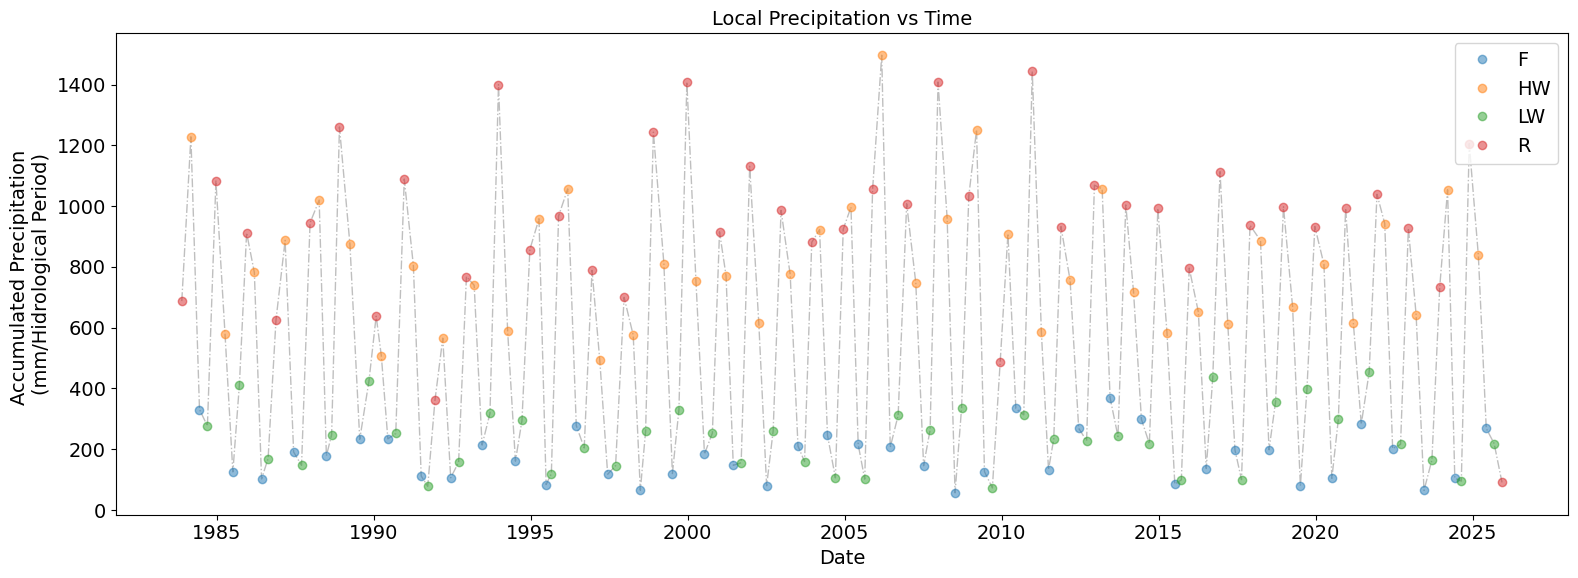

In [21]:
# Create and display time series plot for local watershed accumulated precipitation over time
prepare_time_series_plot(df, 'mean_loc_chirps', "Local Precipitation")

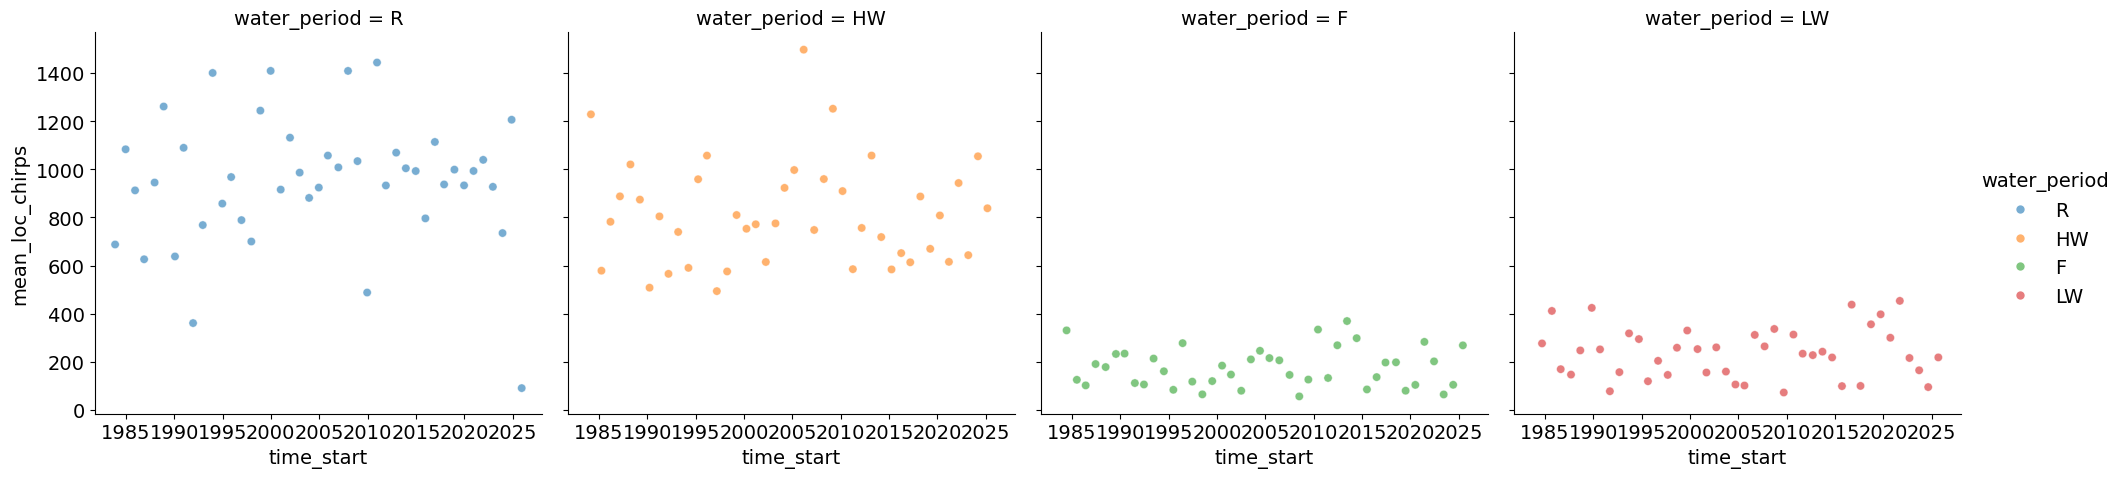

In [22]:
# Create separate scatter plots showing local precipitation for each water period over time
sns.relplot(data=df, x='time_start', y='mean_loc_chirps', alpha=.6, hue='water_period', col='water_period')

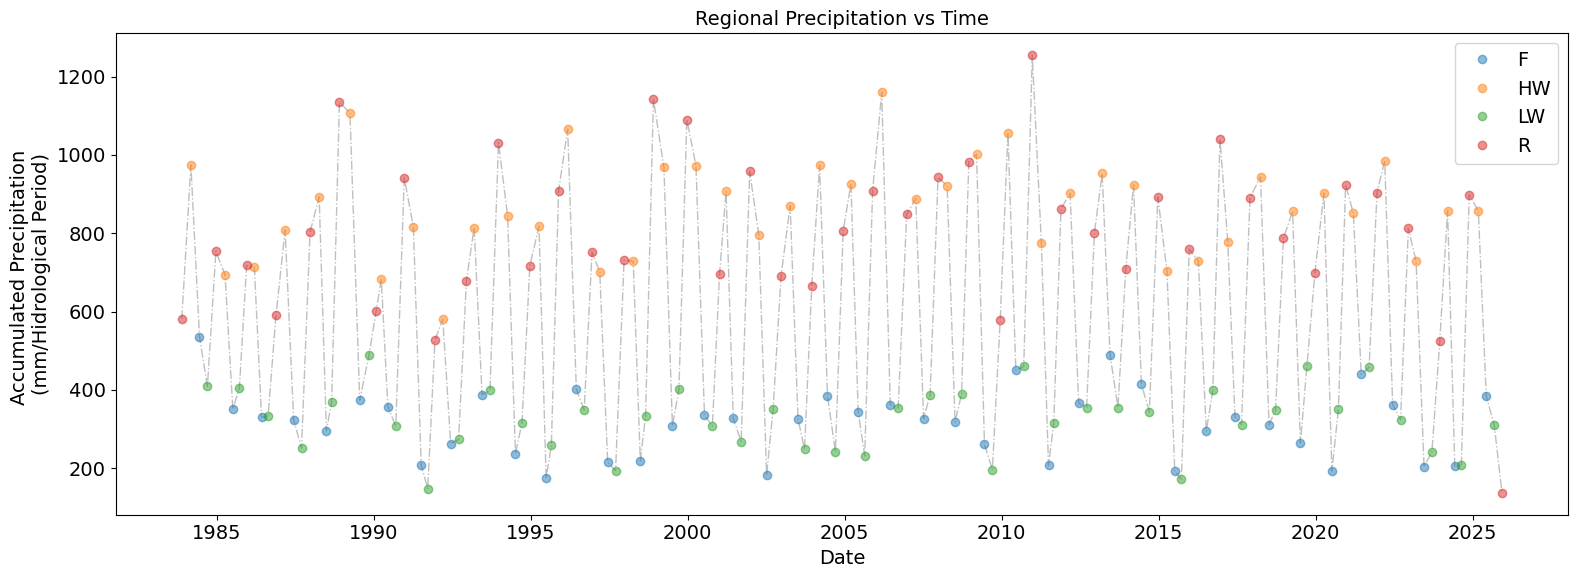

In [23]:
# Create and display time series plot for regional watershed accumulated precipitation over time
prepare_time_series_plot(df, 'mean_reg_chirps', "Regional Precipitation")

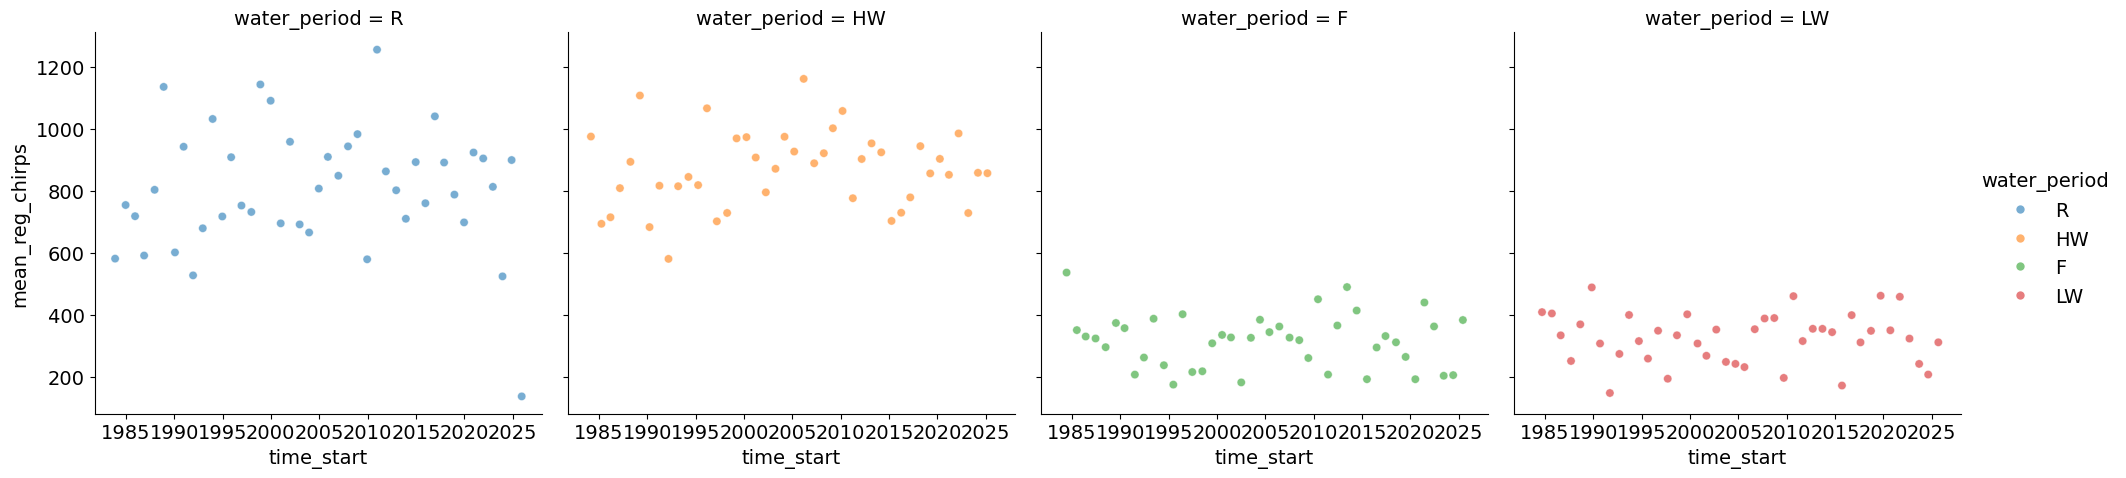

In [24]:
# Create separate scatter plots showing regional precipitation for each water period over time
sns.relplot(data=df, x='time_start', y='mean_reg_chirps', alpha=.6, hue='water_period', col='water_period')